# Sprint 10 - Modelos de Clasificación (Sesiones)

En el presente caso de estudio continuaremos profundizando en el desarrollo de modelos de aprendizaje computacional supervisado para **clasificación**, abordando algunas de las técnicas más utilizadas en proyectos reales de ciencia de datos. Hasta este punto, hemos ya aprendido que el objetivo de este tipo de los modelos es utilizar información histórica para aprender patrones que permitan predecir el valor de una variable objetivo no numérica sobre nuevas observaciones.

Sin embargo, la construcción de un modelo predictivo efectivo no depende únicamente de seleccionar un algoritmo y entrenarlo sobre los datos disponibles. En la práctica, una parte importante del trabajo consiste en preparar adecuadamente la información para que pueda ser utilizada por los algoritmos de aprendizaje automático. De hecho, es común que el esfuerzo dedicado a la preparación y transformación de los datos supere ampliamente al tiempo invertido en la construcción del modelo propiamente dicho. Por esta razón, en este caso estudiaremos algunas técnicas que permiten mejorar la calidad de los datos de entrada y, en consecuencia, aumentar el desempeño de nuestros modelos de clasificación. En concreto, nos enfocaremos en las siguientes:

* **Codificación de variables no numéricas**: muchos algoritmos de aprendizaje automático trabajan exclusivamente con valores numéricos. Por ello, cuando se dispone de variables categóricas o textuales, es necesario transformarlas a representaciones numéricas que puedan ser interpretadas por el modelo sin perder información relevante.
* **Escalamiento de variables numéricas**: las variables suelen encontrarse medidas en diferentes unidades y magnitudes. Mientras algunas pueden tomar valores pequeños, otras pueden presentar rangos considerablemente mayores. El escalamiento permite homogeneizar estas diferencias para evitar que ciertas variables tengan una influencia desproporcionada durante el proceso de entrenamiento del modelo.
* **Balanceo de clases en la variable objetivo**: en muchos problemas reales algunas categorías aparecen con mucha mayor frecuencia que otras. Esta situación puede provocar que el modelo aprenda sesgos hacia la clase predominante y presente un bajo desempeño en la identificación de casos menos frecuentes. Las técnicas de balanceo buscan reducir este problema y mejorar la capacidad predictiva del modelo sobre todas las clases de interés, independiente de su probabilidad de ocurrencia.
* **Ajuste de hiperparámetros**: los algoritmos de aprendizaje automático suelen poseer configuraciones internas que influyen en su comportamiento y desempeño. Estas configuraciones, conocidas como hiperparámetros, no son aprendidas automáticamente a partir de los datos, sino que deben ser definidas y optimizadas por el científico de datos para obtener mejores resultados.

Como algoritmo de clasificación en este caso utilizaremos la **Regresión Logística**, uno de los algoritmos básicos más importantes y ampliamente utilizados dentro del aprendizaje supervisado. A pesar que su nombre puede prestarse a confusión, el mismo está diseñado para resolver problemas de clasificación y no de regresión. Su popularidad se debe a que combina simplicidad, interpretabilidad y un desempeño competitivo en una gran variedad de problemas reales. Además, constituye una excelente herramienta para comprender conceptos fundamentales asociados a la probabilidad, la clasificación y la evaluación de modelos predictivos.

Ahora bien, más allá de las técnicas específicas que estudiaremos, es importante recordar que la construcción de modelos de aprendizaje automático debe seguir una metodología estructurada. Un buen modelo no surge únicamente de aplicar algoritmos, sino de comprender adecuadamente el problema que se desea resolver y de seguir un proceso ordenado de análisis y desarrollo. Por ello, en este y en futuros proyectos, seguiremos el siguiente flujo de trabajo:

* **Entendimiento del contexto**: comprender el problema de negocio o investigación que motiva el análisis, así como los objetivos y metas estratégicos que se espera cumplir mediante el modelo.
* **Entendimiento de los datos**: explorar las características de la información disponible, identificar limitaciones, inconsistencias y patrones relevantes para el problema. En algunos casos, este entendimiento incluirá un **EDA** que permita profundizar aún más en las características y comportamientos de las variables.
* **Preparación de datos**: limpiar, transformar y organizar la información para asegurar su calidad y adecuación al proceso de modelado.
* **Ingeniería de datos**: crear nuevas variables o transformar las existentes para capturar mejor la información relevante y potenciar la capacidad interpretativa y predictiva de los modelos.
* **Creación de un modelo base**: desarrollar una primera versión del modelo que sirva como referencia para evaluar mejoras posteriores.
* **Optimización del modelo**: aplicar técnicas de ajuste y mejora que permitan incrementar el desempeño predictivo y la capacidad predictiva del algoritmo en entornos reales de funcionamiento.

La aplicación sistemática de estas etapas te permitirá construir modelos más robustos, interpretables y útiles para la toma de decisiones, además de ayudarte a establecer una metodología de trabajo reutilizable en proyectos futuros de ciencia de datos.

## Entendimiento del contexto

Una empresa dedicada al alquiler de vehículos de alta gama ha decidido fortalecer sus capacidades analíticas con el objetivo de optimizar sus procesos de captación y conversión de clientes. La organización opera en múltiples países y atiende a una amplia variedad de segmentos, incluyendo turistas de alto poder adquisitivo, ejecutivos corporativos, clientes de lujo y usuarios que requieren servicios especializados de movilidad. Como resultado de sus actividades comerciales y de marketing, la empresa recibe diariamente cientos de solicitudes de información provenientes de potenciales clientes, comúnmente conocidos como *leads*.

Sin embargo, no todos los leads presentan la misma probabilidad de convertirse en una venta efectiva. Algunos clientes potenciales muestran un interés genuino en contratar el servicio y poseen características que históricamente se han asociado con una alta tasa de conversión. Otros en cambio, pueden encontrarse únicamente explorando alternativas, comparando precios o solicitando información sin una intención clara de contratación. Debido a esta diferencia de comportamientos, las unidades de venta y marketing de la empresa consideran estratégico poder estimar anticipadamente la probabilidad de conversión de cada nuevo lead utilizando la información disponible al momento de su contacto inicial.

Para el área de ventas, disponer de una predicción temprana representa una oportunidad importante para optimizar la asignación de recursos y esfuerzos comerciales. En lugar de dedicar el mismo nivel de atención a todos los prospectos, la empresa podría priorizar sus acciones en función de la probabilidad estimada de conversión. Por ejemplo, aquellos leads con una alta probabilidad de concretar una contratación podrían ser gestionados mediante procesos comerciales más estandarizados o por ejecutivos con menor experiencia, mientras que los casos con menor probabilidad de conversión podrían ser asignados a profesionales con mayor experiencia y capacidad de negociación. De esta manera, la organización podría incrementar la eficiencia de sus equipos comerciales y mejorar el aprovechamiento de sus recursos humanos.

Desde la perspectiva de marketing, el análisis también aportaría beneficios significativos. Comprender qué características presentan los leads que finalmente se convierten en clientes permite evaluar la calidad de las campañas de captación realizadas en el pasado y determinar si la inversión publicitaria está atrayendo prospectos alineados con los objetivos del negocio. Asimismo, esta información puede utilizarse para diseñar estrategias futuras más efectivas, identificando segmentos de mercado con mayor potencial de conversión y orientando los presupuestos de marketing hacia canales, perfiles y audiencias que generen mejores resultados.

Con el propósito de apoyar estas decisiones, la empresa te ha contratado como científico de datos para desarrollar un modelo predictivo capaz de clasificar nuevos leads según su probabilidad de convertirse en una venta. Para ello, dispondrás de información histórica sobre clientes potenciales y sus resultados finales, la cual servirá para entrenar un modelo supervisado de **clasificación**. El objetivo final será construir una herramienta que permita anticipar el comportamiento de futuros prospectos, contribuyendo tanto a una gestión comercial más eficiente como a una estrategia de marketing más precisa y rentable.

## Entendimiento de los datos

Antes de iniciar, carga las librerías y funciones que vas a utilizar. Ya conoces la función `train_test_split` y el módulo `metrics` de **Skicit-Learn**. Además de estas, carga las funciones listadas a continuación:

* `StandardScaler` del módulo `preprocessing`.
* `LogisticRegression` del módulo `linear_model`.
* `permutacion_importance`del módulo `inspection`.

Una librería adicional que vamos a utilizar en este caso es **imblearn** que contiene funciones y métodos para corregir problemas de balanceo en variables. Importa también de aquí la función `SMOTE` perteneciente al módulo `over_sampling`.

In [1]:
# Cargar librerias para manejo de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar librerías para ingeniería y modelamiento
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

La empresa de alquiler ha compartido contigo un dataset llamado [**leads.xlsx**](https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/leads.xlsx), que debes cargar a continuación de tal forma que la columna "id" que allí aparece actúe como índice del dataset.

In [2]:
# Cargar datos
df_leads = pd.read_excel("https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/leads.xlsx", index_col = "id")

# Mostrar estructura de los datos
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 4308 entries, 1 to 4308
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   producto               4308 non-null   str  
 1   sexo                   4308 non-null   str  
 2   dominio_email          4308 non-null   str  
 3   grupo_geografico       4308 non-null   str  
 4   fuente                 4308 non-null   str  
 5   pautado                4308 non-null   int64
 6   fecha_creacion         4308 non-null   str  
 7   fecha_conversion       1385 non-null   str  
 8   fecha_descalificacion  3007 non-null   str  
 9   estado                 4308 non-null   int64
dtypes: int64(2), str(8)
memory usage: 522.8 KB


Esta tabla contiene información histórica de poco más de 4,300 *leads* levantados por la empresa entre 2023 y 2024, que incluye las siguientes columnas:

* producto: Nombre del producto de interés para el lead entre las opciones A, B y C.
* sexo: Sexo del lead (F = Mujer, M = Hombre).
* dominio_email: Dominio del correo electrónico del lead.
* grupo_geografico: Región geográfica en la que reside el lead (Estados Unidos, Europa, Latinoamerica, Oceania y Otros).
* fuente: Forma en que se contactó el lead con la empresa (Web = Página web, Remoto = Teléfono, Directo = Local físico, Red Social).
* pautado: Si el lead se contactó con la empresa debido a una campaña de marketing.
* fecha_creacion: Fecha en la que se dio el contacto entre el lead y la empresa.
* fecha_conversion: De ser el caso, fecha en la que se convirtió el lead en una venta.
* fecha_descalificacion: De ser el caso, fecha en que la empresa decidió terminal el contacto, y por ende se perdió la venta del lead.
* estado: Si el lead se convirtió en venta (=1), o si se descalificó (=0).

Explora el dataset y a partir de esto define lo siguiente:

* Objetivo técnico del modelo.
* Algoritmo y métricas de rendimiento a considerar. Esto es nuevo, pero ya puedes definirlo en base a lo previso en la introducción de este documento y en el entendimiento del contexto.
* Plan de acción para preparación e ingeniería los datos, donde se incluyan las dos primeras actividades previstas en la introducción.

In [3]:
# Generar una muestra de los datos
df_leads.sample(10)

,producto,sexo,dominio_email,grupo_geografico,fuente,pautado,fecha_creacion,fecha_conversion,fecha_descalificacion,estado
id,,,,,,,,,,
2948,A,F,gmail,Oceania,Web,0,2023-10-16,NaN,2023-10-31,0
2632,B,F,gmail,Estados Unidos,Remoto,0,2023-12-08,2023-12-08,NaN,1
2093,A,F,icloud,Estados Unidos,Web,0,2023-08-05,NaN,2023-08-07,0
3559,A,M,gmail,Estados Unidos,Directo,0,2024-04-06,NaN,2024-04-29,0
3574,B,F,outlook,Oceania,Remoto,0,2024-03-27,2024-03-27,NaN,1
3331,B,M,yahoo,Estados Unidos,Web,0,2024-02-26,NaN,2024-03-12,0
3142,A,M,outlook,Europa,Directo,0,2024-02-02,NaN,2024-06-02,0
1624,A,M,gmail,Otros,Web,0,2023-04-22,NaN,2023-04-30,0
1280,A,F,live,Latinoamerica,Remoto,0,2023-03-16,NaN,2023-08-25,0


In [4]:
# Generar un conteo de las observaciones por estado
df_leads["estado"].value_counts(normalize = True)

estado
0    0.678505
1    0.321495
Name: proportion, dtype: float64

In [5]:
# Visualizar la probabilidad de que el lead sea "venta" dado el producto
pd.crosstab(
    df_leads["producto"],
    df_leads["estado"],
    normalize = "index"
).loc[:,1].round(4).sort_values(ascending = False)

producto
B    0.4533
C    0.3504
A    0.2067
Name: 1, dtype: float64

In [6]:
# Visualizar la probabilidad de que el lead sea "venta" dado el sexo
pd.crosstab(
    df_leads["sexo"],
    df_leads["estado"],
    normalize = "index"
).loc[:,1].round(4).sort_values(ascending = False)

sexo
M    0.3418
F    0.3089
Name: 1, dtype: float64

In [7]:
# Visualizar la probabilidad de que el lead sea venta "venta" dado el dominio de email
pd.crosstab(
    df_leads["dominio_email"],
    df_leads["estado"],
    normalize = "index"
).loc[:,1].round(4).sort_values(ascending = False)

dominio_email
mac           0.4286
me            0.4167
icloud        0.4091
outlook       0.3974
verizon       0.3810
comcast       0.3671
msn           0.3556
gmail         0.3351
btinternet    0.2857
aol           0.2849
yahoo         0.2838
live          0.2667
hotmail       0.2458
Name: 1, dtype: float64

In [8]:
# Visualizar la probabilidad de que el lead sea "venta" dado el grupo geografico
pd.crosstab(
    df_leads["grupo_geografico"],
    df_leads["estado"],
    normalize = "index"
).loc[:,1].round(4).sort_values(ascending = False)

grupo_geografico
Estados Unidos    0.3490
Oceania           0.3163
Otros             0.2625
Europa            0.2579
Latinoamerica     0.2210
Name: 1, dtype: float64

In [9]:
# Visualizar la probabilidad de que el lead sea "venta" dado la fuente
pd.crosstab(
    df_leads["fuente"],
    df_leads["estado"],
    normalize = "index"
).loc[:,1].round(4).sort_values(ascending = False)

fuente
Remoto        0.7260
Web           0.2865
Directo       0.0915
Red social    0.0310
Name: 1, dtype: float64

In [10]:
# Visualizar la probabilidad de que el lead sea "venta" dado el pautaje
pd.crosstab(
    df_leads["pautado"],
    df_leads["estado"],
    normalize = "index"
).loc[:,1].round(4).sort_values(ascending = False)

pautado
0    0.3772
1    0.0672
Name: 1, dtype: float64

**OBJETIVO TÉCNICO**

Pronosticar con alta asertividad la variable objetivo estado a partir de los distrintos atributos que tiene el dataset y que incluyen características y comportamientos propios de cada lead. Para esto, se debe crear un modelo supervisado de clasificación que permita predecir si un lead se convertirá en venta (estado = 1) o se descalificará (estado = 0).

Complementario a esto, y en base a los resultados de la exploración realizada conviene demostrar si el modelo considera como relevante los siguientes criterios:

* Los leads que provienen de fuentes remotas (teléfono) son más propensos a convertirse en venta.
* Los leads provenientes de fuentes red social y directo son menos propensos a convertirse en venta. 
* Los leads que llegan por campañas de marketing son menos propensos a convertirse en venta.

**ALGORITMO Y METRICAS DE RENDIMIENTO**

* Algoritmo: **Regresión Logística**.
* Métricas de rendimiento: Exactitud, F1 de la clase "venta".

**PLAN DE ACCIÓN PARA PREPARACIÓN E INGENIERÍA DE DATOS**

| # | Acción de preparación |
| ---- | ---- |
| 1 | Para dar tratamiento a los valores perdidos existentes en las columnas fecha_conversion y fecha_descalificacion, en primera instancia se va a convertir el tipo de estas variables a un formato pertinente datetime, incluyendo también la columna fecha_creación. |
| 2 | A continuación se debe crear una nueva columna que extraiga de estas columnas el "tiempo de vida" que ha tenido cada lead independiente de su estado final alcanzado. Lo anterior en vista que para todos los casos se tiene una u otra fecha. Este cálculo se lo hará restando la fecha de conversión de la fecha de conversión o la fecha de descalificación, según corresponda. |
| 3 | Finalmente, se van a eliminar las columnas originales pues toda su información ya estaría contenida en la nueva variable. |

<br />

| # | Acción de ingeniería |
| ---- | ---- |
| 1 | Se va a iniciar separando las variables que son atributos de aquella que es objetivo (estado). |
| 2 | A continuación codificar atributos no numéricos para que puedan ser interpretados por el algoritmo a implementar. |
| 3 | De manera seguida, se va a particionar el dataset en subconjuntos de entrenamiento y prueba. |
| 4 | Para concluir se tiene que escalar los atributos numéricos a fin que todos se encuentren en ordenes de magnitud similares. |

## Preparación de datos

Lleva a cabo tu plan de acción a fin de preparar los datos para las siguientes etapas de análisis.

In [11]:
# Cambiar el tipo de las columnas fecha
df_leads["fecha_creacion"] = pd.to_datetime(df_leads["fecha_creacion"])
df_leads["fecha_conversion"] = pd.to_datetime(df_leads["fecha_conversion"])
df_leads["fecha_descalificacion"] = pd.to_datetime(df_leads["fecha_descalificacion"])
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 4308 entries, 1 to 4308
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   producto               4308 non-null   str           
 1   sexo                   4308 non-null   str           
 2   dominio_email          4308 non-null   str           
 3   grupo_geografico       4308 non-null   str           
 4   fuente                 4308 non-null   str           
 5   pautado                4308 non-null   int64         
 6   fecha_creacion         4308 non-null   datetime64[us]
 7   fecha_conversion       1385 non-null   datetime64[us]
 8   fecha_descalificacion  3007 non-null   datetime64[us]
 9   estado                 4308 non-null   int64         
dtypes: datetime64[us](3), int64(2), str(5)
memory usage: 436.7 KB


In [12]:
# Generar columna tiempo_vida
df_leads["tiempo_vida"] = df_leads["fecha_conversion"] - df_leads["fecha_creacion"]
df_leads.loc[np.isnat(df_leads["tiempo_vida"]),"tiempo_vida"] = df_leads["fecha_descalificacion"] - df_leads["fecha_creacion"]
df_leads["tiempo_vida"] = df_leads["tiempo_vida"].dt.days 
df_leads["tiempo_vida"].describe().round(2)

count    4308.00
mean       68.75
std        91.37
min         0.00
25%         5.00
50%        20.00
75%       111.00
max       659.00
Name: tiempo_vida, dtype: float64

In [13]:
# Eliminar columnas de fechas que ya no se van a utilizar
df_leads = df_leads.drop(columns = ["fecha_creacion","fecha_conversion","fecha_descalificacion"])
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 4308 entries, 1 to 4308
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   producto          4308 non-null   str  
 1   sexo              4308 non-null   str  
 2   dominio_email     4308 non-null   str  
 3   grupo_geografico  4308 non-null   str  
 4   fuente            4308 non-null   str  
 5   pautado           4308 non-null   int64
 6   estado            4308 non-null   int64
 7   tiempo_vida       4308 non-null   int64
dtypes: int64(3), str(5)
memory usage: 369.4 KB


## Ingeniería de datos

Como ya mencionamos, la ingeniería de datos hace referencia a una serie de actividades que permiten "traducir" los datos a un lenguaje comprensible para el algoritmo por implementar en el modelo de aprendizaje. En este sentido, recuerda que habíamos tomado como simil del modelo a un niño aprendiendo a sumar a fin de explicar lo qué hacemos en nuestro modelo. Demos continuidad a esta idea adicionando una premisa nueva:

*Para que nuestro niño aprenda aún mejor, los ejercicios y el examen que le presentemos tienen que ser claros y comprensibles, se deben evitar por tanto todos aquellos elementos que resulten incomprensibles para una persona de su edad y condiciones intelectuales.*

En consecuencia, consideremos que los valores que toman variables no numéricas solamente hacen sentido cuando nosotros como humanos los interpretamos a partir de nuestra experiencia y conceptos adquiridos. Tomemos como ejemplo el valor "Europa" de la columna grupo_geografico; para nosotros queda claro que esta palabra hace referencia al continente que es parte de hemisferio norte de nuestro planeta y donde existen muchos países con millones de habitantes. Sin embargo para un algoritmo esto no es así, pues para él la palabra "Europa" no representa más que una cadena de 6 caraceres en un orden concreto. Es entonces necesario que llevemos estos valores a una representación más comprensible, y qué mejor que utilizar números los cuales sí tienen un significado implícito y conocido por cualquier sistema computacional. 

Visto esto, primero divide el dataset entre sus atributos y la variable objetivo (estado).

In [14]:
X = df_leads.drop(columns = "estado")
y = df_leads["estado"]

A continuación, codifica los atributos tipo texto de forma que se vuelvan numéricos. Te recomiendo usar la función `get_dummies` de **Pandas** con los argumentos adicionales `drop_first = True` y `dtype = int`.

In [15]:
X = pd.get_dummies(
    data = X, 
    drop_first = True, 
    dtype = int
)
print(X.info())
print()
print(X.sample(5).iloc[:,:5])

<class 'pandas.DataFrame'>
RangeIndex: 4308 entries, 1 to 4308
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   pautado                         4308 non-null   int64
 1   tiempo_vida                     4308 non-null   int64
 2   producto_B                      4308 non-null   int64
 3   producto_C                      4308 non-null   int64
 4   sexo_M                          4308 non-null   int64
 5   dominio_email_btinternet        4308 non-null   int64
 6   dominio_email_comcast           4308 non-null   int64
 7   dominio_email_gmail             4308 non-null   int64
 8   dominio_email_hotmail           4308 non-null   int64
 9   dominio_email_icloud            4308 non-null   int64
 10  dominio_email_live              4308 non-null   int64
 11  dominio_email_mac               4308 non-null   int64
 12  dominio_email_me                4308 non-null   int64
 13  dominio_email_

El método de **codificación** que acabas de implementar se conoce como **One-Hot** y es muy utilizado en los procesos de ingeniería de atributos. La idea detrás del mismo es transformar cada valor de una variable no numérica en una columna de tipo buleano como se muestra en la siguiente imagen ejemplificativa:

![](https://github.com/jsaraujo5081/material_curso_data_science/blob/main/complementary_files/ohe.png?raw=true)

En nuestros atributos codificados del dataset solamente ten en cuenta lo siguiente:

* La dimensionalidad (cantidad de variables) del dataset se ha incrementado ya que por cada atributo original ahora existen 1 o más columnas nuevas correspondientes a cada uno de los valores posibles de dicho atributo.
* Mediante el argumento `dtype` se ha cambiado los valores TRUE/FALSE por su equivalente numérico 1/0, respectivamente.
* Mediante el argumento `drop_first` se ha excluido uno de los valores posibles de cada columna original puesto que no entrega ninguna información adicional y es por tanto redundante. Volviendo a nuestra ilustración, nota que si "Y" y "Z" son ambos falsos, la única opción posible es que "X" sea verdadero.

    ![](https://github.com/jsaraujo5081/material_curso_data_science/blob/main/complementary_files/ohe2.png?raw=true)

Solamente queda ajustar los nuevos nombres de las columnas a formato *snake_case*. Haslo.

In [16]:
X.columns = [x.lower().replace(" ","_") for x in X.columns]

Ahora bien, ya tenemos nuestros datos en un modo más comprensible para nuestro algoritmo. Puedes entonces proceder a particionar los datos en los subconjuntos de entrenamiento (75%) y prueba (25%). 

In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size = 0.25, 
    random_state = 123
)
print(X_train.shape)
print(X_valid.shape)

(3231, 24)
(1077, 24)


Consideremos ahora la distribución de los atributos numéricos que mantenemos. Calcula el promedio y la desviación estandar para todas ellas en el conjunto de entrenamiento.

In [18]:
X_train.describe().loc[["mean","std"]].transpose().round(2)

,mean,std
pautado,0.18,0.38
tiempo_vida,69.08,92.12
producto_b,0.45,0.50
producto_c,0.03,0.16
sexo_m,0.38,0.49
dominio_email_btinternet,0.01,0.08
dominio_email_comcast,0.02,0.13
dominio_email_gmail,0.63,0.48
dominio_email_hotmail,0.11,0.31
dominio_email_icloud,0.02,0.14


Notemos que la variable tiempo_vida es particularmente diferente a las demás y esto puede resultar problemático. Para entender el porqué, volvamos a nuestro simil con la siguiente premisa:

*Para que nuestro niño aprenda a sumar correctamente, es importante que entienda que la suma es un proceso transversal y homogeneo a cualquier número, es decir, no existen números más importantes que otros en la operación suma y el orden de los sumandos no altera el resultado. Por ejemplo $2 + 5 = 5 + 2$ o $100 + 81 = 81 + 100$ siempre, y ambos ejercicios siguen el mismo método aritmético.*

Por consiguiente, es importante prevenir que el algoritmo "crea" que un atributo es más relevante que otros solo por mantener un distinto orden de magnitud. Entonces, para arreglar esto se aplica un proceso de ingeniería conocido como **Escalamiento de variables**. Uno de los muchos métodos de escalamiento que existen es el de **Estandarización**, en el cual se transforma una variable $x$ a otra $x_{est}$ mediante la siguiente fórmula:

$$ x_{est} = \frac{x-\bar x}{s_x} $$

donde $\bar x$ es el promedio de dicha variable y $s_x$ es su desviación estandar.

El principal resultado de la estandarización es que el promedio de $x_{est}$ es ahora $0$ y su desviación estandar es $1$, y de ahí su nombre pues recuerda que estos parámetros son los que definen a la centralidad y la escala de una distribución Z (Normal Estandar).

Estandariza entonces la variable tiempo_vida en el subconjunto de entrenamiento utilizando la función `StandardScaler` de **Scikit-Learn**.

In [19]:
# Seleccionar atributo a estandarizar
variable = ["tiempo_vida"]

# Crear modelo de escalamiento y ajustarlo a los datos
mod_escalamiento = StandardScaler()
mod_escalamiento.fit(X_train[variable])

# Transformar atributo con modelo de escalamiento
X_train[variable] = mod_escalamiento.transform(X_train[variable])
print(f"Promedio escalado: {np.mean(X_train[variable]):.1f}")
print(f"Promedio escalado: {np.std(X_train[variable[0]]):.1f}")

Promedio escalado: 0.0
Promedio escalado: 1.0


Estandariza ahora este atributo en el subconjunto de prueba.

In [20]:
X_valid[variable] = mod_escalamiento.transform(X_valid[variable])
print(f"Promedio escalado: {np.mean(X_valid[variable]):.1f}")
print(f"Promedio escalado: {np.std(X_valid[variable[0]]):.1f}")

Promedio escalado: -0.0
Promedio escalado: 1.0


## Creación de modelo base

Como ya mencionamos, en este caso concreto vamos a utilizar el algoritmo básico de **Regresión logística**. Este algoritmo busca clasificar a las distintas obervaciones que se le presenten mediante la estimación de la probabilidad que pertenezcan a una de las clases de la variable objetivo, dado los atributos que dicho registro posee, tal que:

$$ \mathbb{P}(y = 1 \mid X) \propto f(X) = \sum_{x\in X} w_x x = w_{x_1}x_1 + w_{x_2}x_2 + ... $$

donde $w_x$ corresponde a pesos o coeficientes específicos de cada atributo $x$, y se constituyen en parámetros ajustados durante el entrenamiento que no son controlados directamente por nosotros como científicos de datos. 

La expresión "logística" por su parte hace referencia a que esta probabilidad en cuestión surge de aplicar una función logística (también conocida como sigmoidal) de forma que:

$$ \mathbb{P}(y = 1 \mid X) = \frac{1}{1 + \exp \left( -\sum_{x\in X} w_x x \right)} $$

Entonces, si esta probabilidad alcanzada es mayor a un umbral (digamos 0.5) el algoritmo clasificará al registro en el grupo $y = 1$, caso contrario lo hará en $y = 0$. 

La principal ventaja de este algoritmo radica justamente en que utiliza un método probabilístico de clasificación y esto entrega de forma inmediata un grado de certeza respecto a si un caso pronosticado pertenece a uno u otro grupo en particular. Así también, si lo comparamos con los árboles de decisión, tiende a funcionar mejor cuando se utilizan atributos discretos (buleanos) y su grado de *complejidad computacional* es significativamente menor ante dimensionalidades mayores.

En todo caso, entre sus principales desventajas radica el hecho que su visualización no es tan sencilla como lo eran los modelos basados en árboles de decisión. Y otra aún más relevante, en que su funcionamiento asume que las clases a pronosticar son *linealmente separables*, para lo cual se requeriría de una evaluación estadística exhaustiva sobre la interdependencia entre variables (no te preocupes si aún te cuesta comprender estos conceptos, los veremos y aplicaremos en próximos casos).

Visto esto, crea un modelo base con la función `LogisticRegression` y entrénalo con los datos de entrenamiento. Utiliza de forma predeterminada los siguientes argumentos: 

* *solver = "liblinear"* que permite realizar una clasificación binaria como la que deseamos en datos que no son de gran volumetría. 
* *max_iter = 100* que evita que el mecanismo numérico por detrás de la función de **Scikit-Learn** dure un tiempo exchesivo.  

In [21]:
# Definir el modelo
mod_base = LogisticRegression(
    solver = "liblinear", 
    max_iter = 100,
    random_state = 123 # ESte argumento sirve para gneerar replicabilidad de los resultados
)

# Ajustar el modelo a los datos
mod_base.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",123
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

Estima y visualiza la importancia de los distintos atributos aplicando la función `permutation_importance`. Para tu conocimiento, esta función calcula la importancia de cada variable a través de iteraciones en las que permuta aleatoriamente los distintos atributos establecidos y evalúa los cambios en el rendimiento del modelo; si los cambios observados son positivos, entonces el atributo tiene más importancia que uno con cambios negativos. 

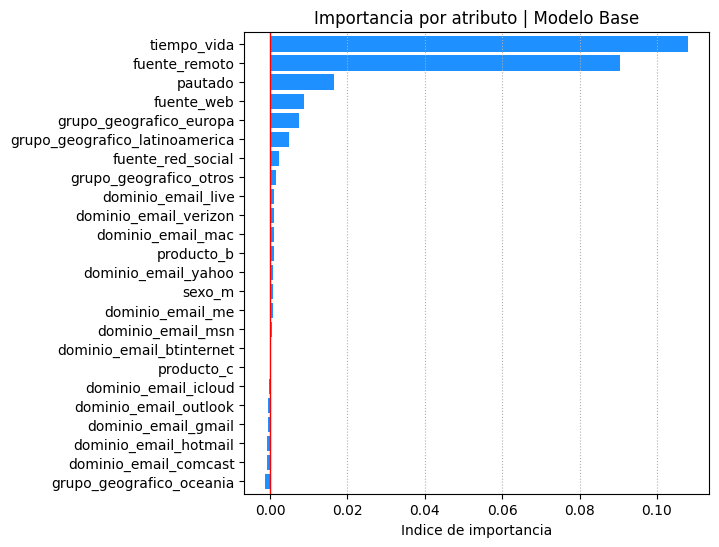

In [22]:
# Calcular importancia de atributos
importancia_atributos = permutation_importance(
    mod_base, 
    X_train, y_train, 
    scoring = "accuracy"
).importances_mean

# Organizar resultados en dataframe
df_importancia = pd.DataFrame(dict(
    importancia = importancia_atributos
), index = X_train.columns)
df_importancia = df_importancia.sort_values(by = "importancia")

# visualizar resultados
df_importancia.plot(
    kind = "barh",
    width = 0.8,
    figsize = [6,6],
    legend = False,
    xlabel = "Indice de importancia",
    title = "Importancia por atributo | Modelo Base",
    color = "dodgerblue"
)

plt.axvline(x = 0, color = "red", linewidth = 1)
plt.grid(axis = "x", linestyle = ":")
plt.show()

Notemos que los atributos tiempo de vida, fuente_remoto y pautado son los más importantes en cuanto a la capacidad predictiva del algoritmo. Esto implica que parte de nuestras hipótesis establecidas en el objetivo técnico se cumplirían satisfactoriamente.

Evalúa ahora el rendimiento del modelo base mediante una matriz de confusión y un reporte de métricas. 

In [23]:
# Generar predicciones
y_pred = mod_base.predict(X_valid)

# Crear matriz de confusion
mat_conf = pd.crosstab(
    y_valid,
    y_pred,
    margins = True,
    rownames = ["Real"],
    colnames = ["Predicho"]
)
print(mat_conf)

Predicho    0    1   All
Real                    
0         636   91   727
1         132  218   350
All       768  309  1077


In [24]:
# Generar reporte de metricas
print(metrics.classification_report(y_valid, y_pred, digits = 3))

              precision    recall  f1-score   support

           0      0.828     0.875     0.851       727
           1      0.706     0.623     0.662       350

    accuracy                          0.793      1077
   macro avg      0.767     0.749     0.756      1077
weighted avg      0.788     0.793     0.789      1077



El modelo base alcanza una exactitud de poco menos del 80%, lo que implica que pronostica bien aproximadamente el estado final de 8 de cada 10 nuevos leads que llegan a la empresa. Sin embargo, vale notar lo siguiente:

* El modelo tiene un mejor rendimiento en su capacidad predictiva de los leads que se descalifican (F1 de 85%) respecto a aquellos que se convierten en venta (F1 de 66%). Esto podría resultar problemático desde el contexto del negocio dado que si se utilizan estos resultados, el equipo comercial gestionaría de forma equivocada sus recursos al asignar leads de alta calidad a ejecutivos con *seniority*, cuando esto no haría falta. Igualmente las inversiones en marketing podrían focalizarse erróneamente, alcanzando a grupos de clientes que no necesitan de estrategias de atracción como promociones.
* Por otra parte, si consideramos que la gran mayoría de los leads de entrenamiento y prueba son de la clase descalificada, es lógico suponer que la capacidad predictiva aquí será mayor simplemente porque el algoritmo ha visto preferentemente estos casos. Lo anterios tenderá a sesgar la exactitud general del modelo llevándonos a la conocida *paradoja de la exactitud*. Esta paradoja dice que cuando la variable objetivo no está balanceada respecto a sus clases, la exactitud no es una métrica confiable de la calidad del modelo.

Por lo expuesto, guarda las métricas de exactitud y el F1 de la clase 1 (venta) alcanzadas por el modelo base.

In [25]:
acc_base = metrics.accuracy_score(y_valid, y_pred)
f1_base = metrics.f1_score(y_valid, y_pred, pos_label = 1)
print(f"Exactitud: {acc_base:.1%}")
print(f"F1 de clase venta: {f1_base:.1%}")

Exactitud: 79.3%
F1 de clase venta: 66.2%


## Optimización del modelo

Recuerda que en esta etapa buscamos maximizar el rendimiento del modelo mediante ajustes técnicos que incrementen los índices de asertividad. En este caso particularmente vamos a enfocarnos en dos procedimientos que nos ayuden a evitar la paradoja de la exactitud, a la vez que nos permitan aumentar los valores de las métricas de rendimiento de la clase "venta". 

### Balanceo de clases

Como su nombre puede ya darnos a entender, el balanceo hace referencia al uso de métodos estadísticos para equilibrar la frecuencia de posibles valores que tome una variable. A continuación te hago mención a los más populares:

* **Submuestreo**: Consiste en eliminar aleatoriamente filas de la clase más frecuente hasta que haya un balance adecuado. Conviene aplicarlo cuando el volumen de datos que se maneja es muy grande y el desbalanceo existente no es tan significativo.
* **Sobremuestreo**: Consiste en simular mediante métodos estadísiticos registros de la clase menos frecuente hasta que se alcance un balance adecuado. Esta simulación puede aplicar diversas procedimientos como el *bootstrap* o el *SMOTE* (que usaremos en este proyecto).
* **Balanceo por pesos**: Este método es específico de algoritmos generadores de parámetros de peso hacia sus atributos (como la regresión logística con el caso de los distintos $w_x$ antes mencionados).

Dado que el primer método es sumamente simple y la cantidad de datos no es excesivamente grande, vamos a obviarlo y a aplicar los otros en nuestro caso.

**Balanceo por pesos**

Este método ajusta los pesos $w_x$ resultantes de la función logística antes descrita mediante un factor inversamente proporcional a la frecuencia de cada clase. De esta manera, para la clase con menos registros en el dataset de entrenamiento se asigna una mayor relevancia que para la otra.

Aplica entonces este método en un modelo nuevo y evalúa su rendimiento en cuanto a las métricas relevantes. Para esto, incorpora el argumento `class_weight = "balanced"` en la definición del modelo.

In [26]:
#Definir el modelo
mod_bw = LogisticRegression(
    solver = "liblinear", 
    max_iter = 100,
    random_state = 123,
    class_weight = "balanced"    
)

#Ajustar el modelo a los datos
mod_bw.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",123
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [27]:
# Generar predicciones
y_pred = mod_bw.predict(X_valid)

# Crear matriz de confusion
mat_conf = pd.crosstab(
    y_valid,
    y_pred,
    margins = True,
    rownames = ["Real"],
    colnames = ["Predicho"]
)
print(mat_conf)

Predicho    0    1   All
Real                    
0         552  175   727
1          40  310   350
All       592  485  1077


In [28]:
# Generar reporte de metricas
print(metrics.classification_report(y_valid, y_pred, digits = 3))

              precision    recall  f1-score   support

           0      0.932     0.759     0.837       727
           1      0.639     0.886     0.743       350

    accuracy                          0.800      1077
   macro avg      0.786     0.822     0.790      1077
weighted avg      0.837     0.800     0.806      1077



Por una parte, notemos que la exactitud sube marginalmente respecto al modelo base, pero dado que este nuevo modelo ha sido balanceado, podemos tener más confianza del valor alcanzado que ya no está sesgado. Adicionalmente, el balanceo permitió un mejor rendimiento predictivo para los casos de leads que se convierten en venta, lo cual es algo que deseábamos hacer en principio.

**Balanceo SMOTE**

El método *SMOTE* (Synthetic Minority Oversampling Technique) funciona de la siguiente manera:

1. Se escoge un dato cualquiera de la clase menos frecuente. 
2. Se determinan los datos que representan sus vecinos más cercanos (igual de la clase menos frecuente) y se escoge uno de ellos al azar.
3. Se crea un nuevo dato "sintético" seleccionando un punto intermedio aleatorio que esté ubicado entre el dato originalmente seleccionado y su vecino escogido.
4. Se repite este proceso un número de veces tal que la cantidad de datos creados compense lo más posible el desbalanceo original.

Aplica este balanceo en los datos de entrenamiento con la función `SMOTE` y el método `fit_resample`, y verifica que se hayan balanceado las clases de la variable objetivo.

In [29]:
# Crear modelo de balance
mod_smote = SMOTE(random_state = 123)

# Transformar datos de entrenamiento con SMOTE
X_train_s, y_train_s = mod_smote.fit_resample(X_train, y_train)

# Verificar que se hayan balanceado las clases
y_train_s.value_counts()

estado
0    2196
1    2196
Name: count, dtype: int64

Crea, entrena y evalúa un nuevo modelo con estos datos balanceados.

In [30]:
#Definir el modelo
mod_bs = LogisticRegression(
    solver = "liblinear", 
    max_iter = 100,
    random_state = 123   
)

#Ajustar el modelo a los datos
mod_bs.fit(X_train_s, y_train_s)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",123
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [31]:
# Generar predicciones
y_pred = mod_bs.predict(X_valid)

# Crear matriz de confusion
mat_conf = pd.crosstab(
    y_valid,
    y_pred,
    margins = True,
    rownames = ["Real"],
    colnames = ["Predicho"]
)
print(mat_conf)

Predicho    0    1   All
Real                    
0         555  172   727
1          41  309   350
All       596  481  1077


In [32]:
# Generar reporte de metricas
print(metrics.classification_report(y_valid, y_pred, digits = 3))

              precision    recall  f1-score   support

           0      0.931     0.763     0.839       727
           1      0.642     0.883     0.744       350

    accuracy                          0.802      1077
   macro avg      0.787     0.823     0.791      1077
weighted avg      0.837     0.802     0.808      1077



Los resultados alcanzados son similares a aquellos obtenidos por el método anterior. Esto no es más que una coincidencia y siempre vale la pena probar diferentes alternativas. Por tanto, te recomiendo que investigues sobre el método de balanceo con *bootstrap* para que amplíes tus herramientas técnicas.

### Ajuste de hiperparámetros

Recuerda que los hiperparámetros consisten en todos aquellos argumentos que podemos controlar como científicos de datos previo a la ejecución de un algoritmo en un modelo de aprendizaje. Y en el caso de modelos de **clasificación** existe uno que no es tan evidente pero resulta múy util conocerlo: el **umbral de clasificación**.

Cuando explicabamos cómo funcionaba el algoritmo de **Regresión logística**, mencionábamos que si la probabilidad obtenida por la función sigmoidal era mayor a un valor de 0.5, entonces la clase asignada para ese caso era 1 (venta). De hecho este criterio está definido de forma automática en nuestro modelo y podríamos cambiarlo estratégicamente para maximizar así la asertividad obtenida en los resultados. Pero, ¿Qué valor es finalmente el óptimo?

Para responder a esta pregunta, primero obtén la probabilidad de conversión predicha para cada lead de prueba dada por nuestro modelo balanceado con *SMOTE*. Utiliza para esto el método `predict_proba`.

In [33]:
# Calcular probabilidad predicha
y_pred_p = mod_bs.predict_proba(X_valid)[:,1]

# Crear dataframe con probabilidades extraidas
df_pred_p = pd.DataFrame(dict(
    clase_real = y_valid,
    clase_predicha_50p = y_pred,
    probabilidad = y_pred_p
), index = X_valid.index)
df_pred_p.sample(15)

,clase_real,clase_predicha_50p,probabilidad
id,,,
3962,0,0,0.168431
698,0,0,0.127500
1620,0,0,0.005287
190,0,0,0.147597
3789,0,1,0.616175
2006,0,0,0.382627
594,0,0,0.207910
2400,1,1,0.658154
2478,1,1,0.918783


Con un umbral de 0.5 obtuvimos un grado de sensibilidad (recall) para la clase 1 de 88.3% debido a que de los 350 casos realmente convertidos en el subconjunto de prueba, 309 fueron correctamente pronosticados (Verdaderos Positivos). Llamemos por tanto a esta tasa por el nombre *TPR: True Positive Rate* tal que

$$ TPR = Recall_{y=1} $$

En línea con esto, se aprecia que existieron 172 Falsos Positivos, es decir, registros que realmente son descalificados pero el modelo predijo como ventas. Si dividimos estos falsos positivos en el total de casos verdaderamente descalificados, obtenemos una métrica conocida como *FPR: False Positive Rate* que en este caso alcanza un valor de 23.7%. Se cumple además que 

$$ FPR = 1 - Recall_{y=0} $$

Si lo pensmos bien, estas métricas deberían cambiar en función del umbral que definamos. Prueba por ejemplo un umbral de 0.4 para calcular el *TPR* y el *FPR*. 

In [34]:
# Generar prediccion con nuevo umbral de 0.4
df_pred_p["clase_predicha_40p"] = df_pred_p["probabilidad"].apply(lambda x: 1 if x > 0.4 else 0)

# Calcular TPR y FPR
tpr_40p = metrics.recall_score(y_valid, df_pred_p["clase_predicha_40p"], pos_label = 1)
fpr_40p = 1 - metrics.recall_score(y_valid, df_pred_p["clase_predicha_40p"], pos_label = 0)
print(f"TPR con umbral 0.4: {tpr_40p:.1%}")
print(f"FPR con umbral 0.4: {fpr_40p:.1%}")

TPR con umbral 0.4: 91.1%
FPR con umbral 0.4: 28.9%


Con este nuevo umbral mejoramos en términos de sensibilidad de la clase 1 (mayor TPR), pero a su vez empeoramos en términos de su especificidad (mayor FPR). Existe por lo tanto un efecto conocido como *trade-off* entre esta métricas, por lo que nuestra meta debe ser encontrar un valor de umbral óptimo que maximice el *TPR* a la vez que minimice el *FPR*, generando por tanto un mejoramiento neto positivo. 

Dado que no es práctico buscar uno a uno todos los posibles umbrales existentes hasta encontrar aquel que es óptimo, puedes utilizar la función `metrics.roc_curve` para generar automáticamente las posibles alternativas.

In [35]:
# Extraer elementos de funcion roc
fpr, tpr, umbral = metrics.roc_curve(y_valid,y_pred_p)

# Guardar elementos en dataframe
df_roc = pd.DataFrame(dict(
    umbral = umbral,
    tpr = tpr,
    fpr = fpr,
))
print(df_roc.head())
print()
print(df_roc.tail())

     umbral       tpr  fpr
0       inf  0.000000  0.0
1  0.958483  0.005714  0.0
2  0.944685  0.020000  0.0
3  0.942292  0.025714  0.0
4  0.936687  0.031429  0.0

       umbral       tpr       fpr
307  0.000801  0.994286  0.983494
308  0.000651  0.994286  0.990371
309  0.000599  0.997143  0.990371
310  0.000078  0.997143  1.000000
311  0.000030  1.000000  1.000000


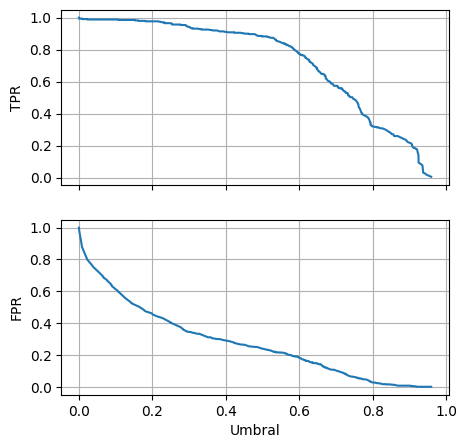

In [36]:
# Visualizar TPR y FPR por niveles de umbral 
fig, ax = plt.subplots(2, sharex = True, figsize = [5,5])
ax[0].plot(
    df_roc["umbral"],
    df_roc["tpr"]
)
ax[0].grid()
ax[0].set_ylabel("TPR")
ax[1].plot(
    df_roc["umbral"],
    df_roc["fpr"]
)
ax[1].grid()
ax[1].set_ylabel("FPR")
ax[1].set_xlabel("Umbral")
plt.show()

Grafica ahora el *TPR* versus el *FPR* para todos los umbrales posibles. Incluye en el gráfico el punto donde se encuentran estas métricas para el umbral automático (0.5).

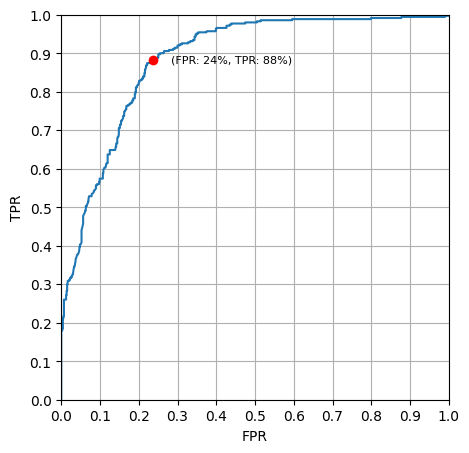

In [37]:
# Calcular TPR y FPR con umbral de 0.5
tpr_50p = metrics.recall_score(y_valid, df_pred_p["clase_predicha_50p"], pos_label = 1)
fpr_50p = 1 - metrics.recall_score(y_valid, df_pred_p["clase_predicha_50p"], pos_label = 0)

# Visualizar TPR vs FPR
df_roc.plot(
    x = "fpr",
    y = "tpr",
    legend = False,
    grid = True,
    figsize = [5,5],
    ylim = [0,1],
    xlim = [0,1],
    xticks = np.array(range(0,110,10))/100,
    yticks = np.array(range(0,110,10))/100,
    ylabel = "TPR",
    xlabel = "FPR"
)
plt.plot(fpr_50p, tpr_50p, marker = "o", color = "red")
plt.annotate(
    text=f"(FPR: {fpr_50p:.0%}, TPR: {tpr_50p:.0%})",
    xy=[fpr_50p*1.2, tpr_50p],
    va="center",
    ha="left",
    fontsize = 8
)
plt.show()

La curva obtenida se conoce como **Curva ROC (Receiver Operating Characteristic)** y tiene su origen en los estudios físicos de detección de señales, lo cual explica su nombre. Independiente de su origen, su utilidad en modelos de clasificación radica en que nos va a permitir encontrar el punto óptimo del umbral.

Pensemos en lo siguiente: si seleccionamos un umbral que suba el *TPR* a 95% (+7pp), el *FPR* alcanzará un valor de aproximadamente 35% (+11pp); entonces el beneficio es menor al costo de esta estrategia y no conviene hacerla. Esta lógica simple nos da cuenta que de hecho deberíamos movernos en el otro sentido de la curva (reducir *TPR* y *FPR*). Pero para saber hasta dónde hacerlo, incluye en el gráfico anterior una recta con intercepto 1 y pendiente -1. 

Vale aclarar que la intersección entre esta recta y la curva ROC es el punto óptimo buscado, y para entender la razón de esto te sugiero que pienses el porqué de esta particularidad geométrica.

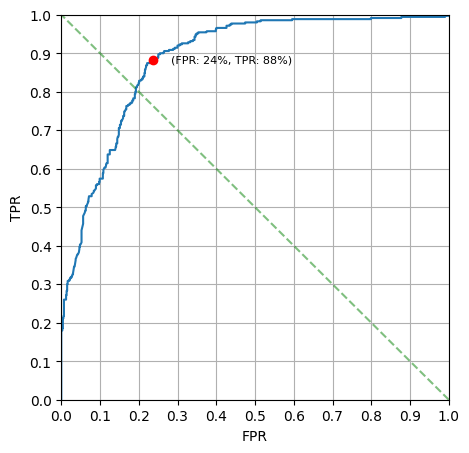

In [38]:
df_roc.plot(
    x = "fpr",
    y = "tpr",
    legend = False,
    grid = True,
    figsize = [5,5],
    ylim = [0,1],
    xlim = [0,1],
    xticks = np.array(range(0,110,10))/100,
    yticks = np.array(range(0,110,10))/100,
    ylabel = "TPR",
    xlabel = "FPR"
)
plt.plot(fpr_50p, tpr_50p, marker = "o", color = "red")
plt.annotate(
    text=f"(FPR: {fpr_50p:.0%}, TPR: {tpr_50p:.0%})",
    xy=[fpr_50p*1.2, tpr_50p],
    va="center",
    ha="left",
    fontsize = 8
)
plt.plot([1,0], [0,1], linestyle='--',color = "green", alpha = 0.5)
plt.show()

Encuentra entonces el valor del umbral en el que se da esta intersección y visualízalo en la gráfica anterior. En otras palabras, encuentra en qué punto se cumple que 

$$ TPR = 1 - FPR $$

In [39]:
# Encontrar el umbral optimo 
df_roc["1_fpr"] = 1 - df_roc["fpr"]
df_roc["optimo"] = round(df_roc["1_fpr"],2) == round(df_roc["tpr"],2)
umbral_opt = df_roc.query("optimo")["umbral"].mean()
print(f"Umbral optimo: {umbral_opt:.1%}")

Umbral optimo: 58.2%


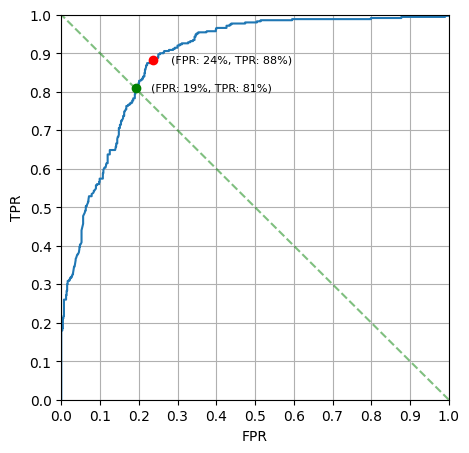

In [40]:
# Visualizar el umbral óptimo en la curva ROC
tpr_opt = df_roc.query("optimo")["tpr"].mean()
fpr_opt = df_roc.query("optimo")["fpr"].mean()

df_roc.plot(
    x = "fpr",
    y = "tpr",
    legend = False,
    grid = True,
    figsize = [5,5],
    ylim = [0,1],
    xlim = [0,1],
    xticks = np.array(range(0,110,10))/100,
    yticks = np.array(range(0,110,10))/100,
    ylabel = "TPR",
    xlabel = "FPR"
)
plt.plot(fpr_50p, tpr_50p, marker = "o", color = "red")
plt.annotate(
    text=f"(FPR: {fpr_50p:.0%}, TPR: {tpr_50p:.0%})",
    xy=[fpr_50p*1.2, tpr_50p],
    va="center",
    ha="left",
    fontsize = 8
)
plt.plot([1,0], [0,1], linestyle='--',color = "green", alpha = 0.5)
plt.plot(fpr_opt, tpr_opt, marker = "o", color = "green")
plt.annotate(
    text=f"(FPR: {fpr_opt:.0%}, TPR: {tpr_opt:.0%})",
    xy=[fpr_opt*1.2, tpr_opt],
    va="center",
    ha="left",
    fontsize = 8
)
plt.show()

### Modelo óptimo balanceado y con umbral ajustado

Ya tenemos todo lo necesario. Evalúa el rendimiento del modelo balanceado pero considerando el umbral óptimo encontrado.  

In [41]:
# Generar prediccion con umbral óptimo
y_pred = df_pred_p["probabilidad"].apply(lambda x: 1 if x > umbral_opt else 0)

# Crear matriz de confusion
mat_conf = pd.crosstab(
    y_valid,
    y_pred,
    margins = True,
    rownames = ["Real"],
    colnames = ["Predicho"]
)
print(mat_conf)

Predicho    0    1   All
Real                    
0         587  140   727
1          67  283   350
All       654  423  1077


In [42]:
# Generar reporte de metricas
print(metrics.classification_report(y_valid, y_pred, digits = 3))

              precision    recall  f1-score   support

           0      0.898     0.807     0.850       727
           1      0.669     0.809     0.732       350

    accuracy                          0.808      1077
   macro avg      0.783     0.808     0.791      1077
weighted avg      0.823     0.808     0.812      1077



Guarda las métricas relevantes para el modelo óptimo y contrasta estos resultados con tu modelo base.

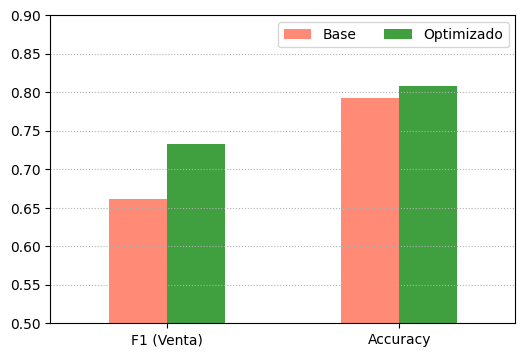

In [43]:
# Metricas del modelo óptimo
acc_opt = metrics.accuracy_score(y_valid, y_pred)
f1_opt = metrics.f1_score(y_valid, y_pred, pos_label = 1)

# Consolidar metricas
metricas_base = [f1_base, acc_base]
metricas_opt = [f1_opt, acc_opt]

df_metricas = pd.DataFrame(dict(
    Base = metricas_base,
    Optimizado = metricas_opt
), index = ["F1 (Venta)", "Accuracy"])

# Comparar visualmente resultados alcanzados
df_metricas.plot(
    kind = "bar",
    ylim = [0.5,0.9],
    figsize = [6,4],
    rot = 0,
    color = ["tomato","green"],
    alpha = 0.75
)
plt.legend(ncol = 2)
plt.grid(axis = "y", linestyle = ":")
plt.show()


¡Listo! Has generado un modelo optimizado y confiable para pronosticar si un lead se convertirá en venta y que además tiene un valor de negocio importante al ser de utilidad para la toma de decisiones de los equipos comeciales y de marketing de la empresa de alquiler. 

Ten en cuenta que siempre hay espacio de mejora, y si gustas puedes intentar otras alternativas tanto en ingeniería de datos como en optimización del modelo. Por ahora, para ser una primera versión, puedes estar seguro que tienes un gran modelo predictivo.